![header](../figures/logos_partenaires._cmems_se.jpg)

# Benchmark DUACS sea surface height maps

<div style="text-align: right"><i> 2023-04-27 DUACS_SSH_BENCHMARK_DEMO </i></div>

***
**Authors:**  CLS & Datlas <br>
**Copyright:** 2023 CLS & Datlas <br>
**License:** MIT

<div class="alert alert-block alert-success">
<h1><center>Benchmark of DUACS sea surface height maps</center></h1>
<h5> The notebook aims to evaluate the sea surface height maps produced by the DUACS system. </h5>
    <h5> These maps are equivalent to the SEALEVEL_GLO_PHY_L4_MY_008_047 product distributed by the Copernicus Marine Service, except that a nadir altimeter (SARAL/Altika, SEALEVEL_GLO_PHY_L3_MY_008_062 product) has been excluded from the mapping. </h5>
        <h5> We provide below a demonstration of the validation of these maps against the independent SSH data from the Saral/AltiKa altimeter distributed by CMEMS </h5>
</div>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Cell" and select "Run All Above Selected Cell".<br>
***


<div class="alert alert-danger" role="alert">

<h3>Learning outcomes</h3>

At the end of this notebook you will know:
<ul>
  <li>How you can evaluated sea surface height maps with independent alongtrack data: statistical and spectral analysis</li>
</ul>
    
</div>

In [3]:
#%pip install hvplot

Note: you may need to restart the kernel to use updated packages.


In [6]:
#%pip install --dry-run 'numpy<2' numba

  Using cached numpy-1.24.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
Would install numpy-1.24.4
Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from src.mod_plot import *
from src.mod_stat import *
from src.mod_spectral import *
from src.mod_interp import *
from src.mod_intervals import *
from glob import glob
import numpy as np
import os

In [3]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

<div class="alert alert-info" role="alert">

<h2>0. Parameters</h2>

</div>

In [3]:
time_min = '2023-01-15'                                        # time min for analysis
time_max = '2023-12-15'                                        # time max for analysis
output_dir = '../results'                                      # output directory path
os.system(f'mkdir -p {output_dir}')
method_name = 'GLO12'
stat_output_filename = f'{output_dir}/stat_ssh_glo12.nc'  # output statistical analysis filename
lambda_min = 65.                                               # minimun spatial scale in kilometer to consider on the filtered signal
lambda_max = 500.                                              # maximum spatial scale in kilometer to consider on the filtered signal
psd_output_filename = f'{output_dir}/psd_ssh_glo12.nc'    # output spectral analysis filename
segment_lenght = 1000.                                         # spectral parameer: along-track segment lenght in kilometer to consider in the spectral analysis

<div class="alert alert-info" role="alert">

<h2>1. Input files</h2>

</div>

## Sea Surface Height from Saral/AltiKa

In [5]:
#list_of_file = sorted(glob('/Odyssey/public/altimetry_traces/processed_2023_global_4/dl/ref/alg/**/*2024*/2023/**/*.nc'))
##sorted(glob('../data/independent_alongtrack/alg/2019/*.nc'))
#ds_alg = xr.open_mfdataset(list_of_file, combine='nested', concat_dim='time')
#ds_alg = ds_alg.where((ds_alg.time >= np.datetime64(time_min)) & (ds_alg.time <=  np.datetime64(time_max)), drop=True)
#ds_alg["longitude"] = (ds_alg["longitude"] % 360).where(ds_alg["longitude"] != 360, 0)
#ds_alg['ssh'] = ds_alg['sla_filtered'] + ds_alg['mdt']
#ds_alg = ds_alg.sortby(['time', 'longitude', 'latitude'])
#ds_alg

In [5]:
time_min = '2023-01-15'                                        # time min for analysis
time_max = '2023-12-15'                                        # time max for analysis

list_of_file = sorted(glob('/Odyssey/public/altimetry_traces/processed_2023_global_4/dl/ref/*/**/*2024*/2023/**/*.nc'))

ds_alg = xr.open_mfdataset(list_of_file)
ds_alg = ds_alg.pipe(
lambda d: d.where(
    (d.time.load() >= pd.to_datetime(time_min))
    & (d.time <= pd.to_datetime(time_max)),
    drop=True,
    )
    ).assign(ssh=lambda d: d.sla_filtered + d.mdt).sortby("time")[["ssh", "sla_filtered", "sla_unfiltered", "mdt", "lwe"]]
ds_alg = ds_alg.where((ds_alg.time >= np.datetime64(time_min)) & (ds_alg.time <=  np.datetime64(time_max)), drop=True)

#ds_alg["longitude"] = (ds_alg["longitude"] % 360).where(ds_alg["longitude"] != 360, 0)
ds_alg

<xarray.Dataset> Size: 856MB
Dimensions:         (time: 13380843)
Coordinates:
  * time            (time) datetime64[ns] 107MB 2023-01-15T23:47:29.547174912...
    latitude        (time) float64 107MB -64.98 -64.92 -64.87 ... -63.78 -63.84
    longitude       (time) float64 107MB 110.1 110.1 110.0 ... 271.1 271.0 271.0
Data variables:
    ssh             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    sla_filtered    (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    sla_unfiltered  (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    mdt             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    lwe             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea surface height measured by altimeter...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-3 sea su...
    time_coverage_duration:          P23H11M4.556364S
    time_coverage_end:               2023-01-01T23:27:36Z
    time_coverage_resolution:        P1S
    time_coverage_start:             2023-01-01T00:16:31Z
    title:                           DT Altika Drifting Phase Global Ocean Al...

## Sea Surface Height maps to evaluate

In [4]:
time_min = '2023-01-15'                                        # time min for analysis
time_max = '2023-12-15'

glo12_paths = '/Odyssey/public/glorys/mercator_forecast/glo12/R202*/'
ds_maps = get_preprocessed_rec_mercator_forecast(glo12_paths, leadtime_index=0)
ds_maps = ds_maps - ds_maps.mean(skipna=True)

ds_maps = ds_maps.sel(time=slice(time_min, time_max)).rename({'out':'ssh', 'lat':'latitude', 'lon':'longitude'})
ds_maps

<xarray.Dataset> Size: 3GB
Dimensions:    (latitude: 2041, longitude: 4320, time: 48)
Coordinates:
  * latitude   (latitude) float64 16kB -80.0 -79.92 -79.83 ... 89.83 89.92 90.0
  * longitude  (longitude) float64 35kB -180.0 -179.9 -179.8 ... 179.9 180.0
  * time       (time) datetime64[ns] 384B 2023-01-18 2023-01-25 ... 2023-12-13
Data variables:
    ssh        (time, latitude, longitude) float64 3GB nan nan nan ... nan nan

In [14]:
m_var_glo12, s_var = ds_maps.ssh.pipe(lambda da: (da.mean().values.item(), da.std().values.item()))
m_var, s_var

(0.436163246314526, 0.7174220241913792)

In [15]:
m_var_sat, s_var = ds_alg.ssh.pipe(lambda da: (da.mean().values.item(), da.std().values.item()))
m_var, s_var

(0.436163246314526, 0.6648721041140607)

In [12]:
ds_alg.ssh.pipe(lambda da: (da.min().values.item(), da.max().values.item()))

(-1.6940000000000002, 2.069)

In [13]:
ds_maps.ssh.pipe(lambda da: (da.min().values.item(), da.max().values.item()))

(-2.118519105017185, 1.6976748332381248)

In [17]:
offset_ssh = m_var_sat - m_var_glo12
offset_ssh

0.5201200387686129

In [18]:
ds_alg['ssh'] = ds_alg['ssh'] - offset_ssh

<xarray.DataArray 'ssh' ()> Size: 8B
dask.array<mean_agg-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>

In [24]:
np.nanmean(ds_alg.ssh.values)

np.float64(-0.08395679245408702)

## Time restriction for methods with Intervals between leadtimes

In [36]:
# RESTRICT TIME TO 0.5 DAYS AROUND RECONSTRUCTED LEADTIMES
ds_alg = ds_alg.sel(time=numpy_restrict_time_alongtrack(ds_alg.time.values, ds_maps.time.values, days_offset=5))
ds_alg = ds_alg.sortby(['time', 'longitude', 'latitude'])
ds_alg

<xarray.Dataset> Size: 856MB
Dimensions:         (time: 13380843)
Coordinates:
  * time            (time) datetime64[ns] 107MB 2023-01-15T23:47:29.547174912...
    latitude        (time) float64 107MB -64.98 -64.92 -64.87 ... -63.78 -63.84
    longitude       (time) float64 107MB 110.1 110.1 110.0 ... 271.1 271.0 271.0
Data variables:
    ssh             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    sla_filtered    (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    sla_unfiltered  (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    mdt             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    lwe             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea surface height measured by altimeter...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-3 sea su...
    time_coverage_duration:          P23H11M4.556364S
    time_coverage_end:               2023-01-01T23:27:36Z
    time_coverage_resolution:        P1S
    time_coverage_start:             2023-01-01T00:16:31Z
    title:                           DT Altika Drifting Phase Global Ocean Al...

## Very important manipulation in order to make DC21 notebooks work ! 

In [5]:
ds_maps["longitude"] = (ds_maps["longitude"] % 360).where(ds_maps["longitude"] != 360, 0)
lon_unique, index = np.unique(ds_maps.coords["longitude"], return_index=True)
ds_maps = ds_maps.isel(longitude=index)
ds_maps.latitude.attrs['units'] = 'degrees_north'
ds_maps.longitude.attrs['units'] = 'degrees_east'
ds_maps = ds_maps.sortby(['time', 'longitude', 'latitude'])
ds_maps

<xarray.Dataset> Size: 3GB
Dimensions:    (latitude: 2041, longitude: 4319, time: 48)
Coordinates:
  * latitude   (latitude) float64 16kB -80.0 -79.92 -79.83 ... 89.83 89.92 90.0
  * longitude  (longitude) float64 35kB 0.04168 0.125 0.2084 ... 359.9 360.0
  * time       (time) datetime64[ns] 384B 2023-01-18 2023-01-25 ... 2023-12-13
Data variables:
    ssh        (time, latitude, longitude) float64 3GB nan nan nan ... nan nan

## SLA becomes SSH in our version of evaluation workflow: add MDT as variable to the ds_maps dataset

In [37]:
#mdt_ds = xr.open_dataset("/Odyssey/public/duacs/1993_2013/duacs_global_0.25deg_1993_2013_mdt.nc")
#mdt_3d = np.repeat(mdt_ds.mdt.values[np.newaxis, :, :], 337, axis=0) # 337 days with 15 days missing in the beginning of the year (confirm Pierre)
#ds_maps['mdt'] = (['time', 'latitude', 'longitude'], mdt_3d[:,:]) # 40: only for 4dvarnet

mdt_maps = xr.open_dataset("/Odyssey/public/duacs/1993_2013/duacs_global_0.25deg_1993_2013_mdt.nc").expand_dims({'time': ds_maps.time.values}, axis=0)
mdt_maps["longitude"] = (mdt_maps["longitude"] % 360).where(mdt_maps["longitude"] != 360, 0)
mdt_maps.latitude.attrs['units'] = 'degrees_north'
mdt_maps.longitude.attrs['units'] = 'degrees_east'
mdt_maps = mdt_maps.sortby(['time', 'longitude', 'latitude'])
#.broadcast_like(ds_maps)
#mdt_array = xr.DataArray(
#    data=mdt_map,
#    coords=dict(
#        latitude=ds_maps.latitude.values,
#        longitude=ds_maps.longitude.values,
#    )
#)
#ds_maps['ssh'] = ds_maps['out'] + mdt_map
mdt_maps


<xarray.Dataset> Size: 398MB
Dimensions:    (time: 48, latitude: 720, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 384B 2023-01-18 2023-01-25 ... 2023-12-13
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float64 12kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
Data variables:
    mdt        (time, latitude, longitude) float64 398MB nan nan nan ... nan nan

<div class="alert alert-info" role="alert">

<h2>2. Statistical & Spectral Analysis </h2>

</div>

## 2.1 Interpolate sea surface height maps onto along-track positions

### 2.1.1 Additionally, interpolate mdt from ds_maps onto along-track positions -> changed /src/mod_interp.py

In [50]:
ds_interp = run_interpolation_ssh(ds_maps, ds_alg, var_alongtrack='ssh', var_rec='ssh', forecast_interval=True)
ds_interp_mdt = run_interpolation_ssh(mdt_maps, ds_alg, var_alongtrack='ssh', var_rec='mdt', forecast_interval=True)

2025-01-27 11:55:31 INFO     fetch data from 2023-01-18 00:00:00 to 2023-02-01 00:00:00
2025-01-27 11:55:31 INFO     fetch data from 2023-01-25 00:00:00 to 2023-03-01 00:00:00
2025-01-27 11:55:31 INFO     fetch data from 2023-02-22 00:00:00 to 2023-04-05 00:00:00
2025-01-27 11:55:31 INFO     fetch data from 2023-03-29 00:00:00 to 2023-05-03 00:00:00
2025-01-27 11:55:32 INFO     fetch data from 2023-04-26 00:00:00 to 2023-06-07 00:00:00
2025-01-27 11:55:32 INFO     fetch data from 2023-05-31 00:00:00 to 2023-07-05 00:00:00
2025-01-27 11:55:32 INFO     fetch data from 2023-06-28 00:00:00 to 2023-08-02 00:00:00
2025-01-27 11:55:32 INFO     fetch data from 2023-07-26 00:00:00 to 2023-09-06 00:00:00
2025-01-27 11:55:33 INFO     fetch data from 2023-08-30 00:00:00 to 2023-10-04 00:00:00
2025-01-27 11:55:33 INFO     fetch data from 2023-09-27 00:00:00 to 2023-11-01 00:00:00
2025-01-27 11:55:33 INFO     fetch data from 2023-10-25 00:00:00 to 2023-12-06 00:00:00
2025-01-27 11:55:33 INFO     fet

In [44]:
np.nanmean(mdt_maps.mdt.values)

np.float64(0.2514792899948421)

In [45]:
np.nanmean(ds_interp_mdt.mssh_interpolated.values)

np.float64(0.3425943203433181)

In [39]:
from matplotlib import pyplot as plt

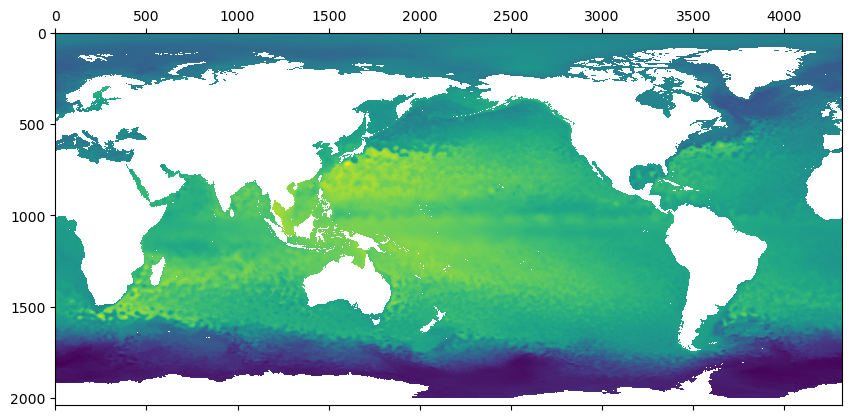

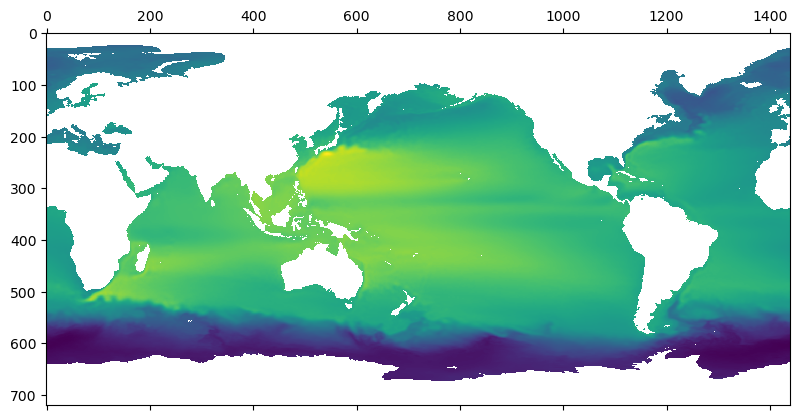

In [40]:
plt.matshow(ds_maps.ssh.values[0,::-1])
plt.matshow(mdt_maps.mdt.values[0,::-1])

### 2.1.2 Now replace SLA from altimeters to SSH: SSH_altimeters = SLA_altimeters + MDT_interpolated

In [46]:
ds_interp['sla_unfiltered'] = ds_interp['sla_unfiltered'] -  ds_interp['lwe'] + ds_interp_mdt['mssh_interpolated'] - offset_ssh
ds_interp['sla_filtered'] = ds_interp['sla_filtered'] -   ds_interp['lwe'] + ds_interp_mdt['mssh_interpolated'] - offset_ssh
ds_interp['msla_interpolated'] = ds_interp['mssh_interpolated']
ds_interp = ds_interp.dropna('time')

## 2.2 Compute grid boxes statistics & statistics by regime (coastal, offshore low variability, offshore high variability)

Once the maps have been interpolated to the position of the along-track, it is possible to calculate different statistics on the time series SLA_alongtrack and SLA_maps. 

We propose below the following statistics: error variance maps (static by 1°x1° box), explained variance maps, temporal evolution of global error variance and explained variance. 

These statistics are also applied to the filtered signals focusing on the 65-500km scale range. A bandpass filter is applied before calculating the scores.  

In [47]:
compute_stat_scores(ds_interp, lambda_min, lambda_max, stat_output_filename, method_name, freq_out='1D', land_sea_mask='/Odyssey/public/data_challenge_ssh_ose/data/sad/land_water_mask_60.nc', variance_ssh='/Odyssey/public/data_challenge_ssh_ose/data/sad/variance_cmems_dt_allsat.nc', distance_to_nearest_coast='/Odyssey/public/data_challenge_ssh_ose/data/sad/distance_to_nearest_coastline_60.nc')

2025-01-27 11:49:44 INFO     Compute mapping error all scales
2025-01-27 11:49:44 INFO     Compute mapping error for scales between 65.0 and 500.0 km


Total RMSE= 0.14372975789641743 m
Total RMSE score= 0.7873662179247736 m


2025-01-27 11:50:30 INFO     Compute binning statistics
2025-01-27 11:50:38 INFO     Compute statistics by oceanic regime
2025-01-27 11:50:58 INFO     Stat file saved as: ../results/stat_ssh_glo12.nc


In [1]:
# Plot gridded stats
# Hvplot
# plot_stat_score_map(stat_output_filename)
# Matplotlib
only_one_plot_stat_score_map(stat_output_filename)

NameError: name 'only_one_plot_stat_score_map' is not defined

In [ ]:
plot_stat_score_timeseries(stat_output_filename)

:Layout
   .Overlay.I  :Overlay
      .Curve.All_scale :Curve   [time]   (timeserie_variance_mapping_err)
      .Curve.Filtered  :Curve   [time]   (timeserie_variance_mapping_err)
   .Overlay.II :Overlay
      .Curve.All_scale :Curve   [time]   (explained_variance_score)
      .Curve.Filtered  :Curve   [time]   (explained_variance_score)

### 2.2.1 I modified /src/mod_stat.py in order to add the computation of nRMSE score for mappieng err; I also modified /src/mod_plot.py in order to include RMSE and nRMSE score to the table

In [49]:
plot_stat_by_regimes(stat_output_filename)

,mapping_err_var [m²],mapping_err_rms,mapping_err_nrms_score,sla_unfiltered_var [m²],sla_unfiltered_rms,sla_unfiltered_nrms_score,mapping_err_filtered_var [m²],mapping_err_filtered_rms,mapping_err_filtered_nrms_score,sla_filtered_var [m²],sla_filtered_rms,sla_filtered_nrms_score,var_score_allscale,var_score_filtered
coastal,0.004727,0.140697,0.791853,0.330185,0.578772,0.791853,0.000918,0.030292,0.791853,0.002557,0.050569,0.791853,0.985685,0.641140
offshore_highvar,0.017836,0.189474,0.719692,0.332705,0.576890,0.719692,0.005556,0.074542,0.719692,0.026181,0.162576,0.719692,0.946390,0.787766
offshore_lowvar,0.003140,0.140313,0.792421,0.486516,0.710146,0.792421,0.000635,0.025203,0.792421,0.002349,0.048495,0.792421,0.993545,0.729590
equatorial_band,0.002274,0.129935,0.807774,0.055645,0.405935,0.807774,0.000412,0.020296,0.807774,0.000651,0.025542,0.807774,0.959137,0.366975
arctic,0.004576,0.160366,0.762755,0.014210,0.749165,0.762755,0.000704,0.026533,0.762755,0.000914,0.030249,0.762755,0.677990,0.230122
antarctic,0.003456,0.131457,0.805523,0.004202,1.721211,0.805523,0.000719,0.026820,0.805523,0.000705,0.026569,0.805523,0.177608,-0.019336


## 2.3 Compute Spectral scores

In [ ]:
compute_psd_scores_v2(ds_interp, psd_output_filename, lenght_scale=segment_lenght,method_name=method_name)

2024-09-11 20:21:28 INFO     Segment computation...
2024-09-11 20:21:40 INFO     Spectral analysis...
2024-09-11 20:36:31 INFO     Saving ouput...
2024-09-11 20:36:40 INFO     PSD file saved as: ../results/psd_sla_duacs_geos.nc


Averaged effective resolution: 326.3135873170383 km


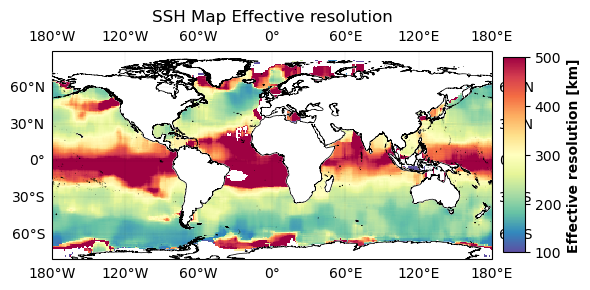

In [6]:
# Plot effective resolution
# Hvplot
# plot_effective_resolution(psd_output_filename)
# Matplotlib
plot_effective_resolution_png(psd_output_filename)

### UV scores

In [6]:
# Constants
g = 9.81  # Gravity (m/s²)
omega = 7.2921e-5  # Earth's rotation rate (rad/s)
lat_to_rad = np.pi / 180.0

def coriolis(lat):
    """Calculate the Coriolis parameter."""
    return 2 * omega * np.sin(lat * lat_to_rad)

def calculate_geostrophic_velocities_cpu(ssh, lat, lon):
    """Calculate geostrophic velocities from SSH."""
    # Calculate spatial gradients of SSH
    dssh_dy = np.gradient(ssh, axis=0)  # Gradient along latitude
    dssh_dx = np.gradient(ssh, axis=1)  # Gradient along longitude

    # Convert lat/lon to meters for gradient scaling
    lat_spacing = np.gradient(lat) * 111e3  # Convert degrees to meters
    lon_spacing = np.gradient(lon) * 111e3 * np.cos(lat[:, None] * lat_to_rad)  # Broadcast lat to match SSH shape

    # Adjust gradients to physical units (m/m)
    dssh_dx /= lon_spacing
    dssh_dy /= lat_spacing[:, None]

    # Coriolis parameter
    f = coriolis(lat)
    #f_masked = np.where(f == 0, np.nan, f)  # Replace zero values with NaN to prevent division by zero
    f_masked = np.where(np.abs(lat) < 1e-5, np.nan, f)

    # Geostrophic velocities
    ugos = -g / f_masked[:, None] * dssh_dy  # u-component
    vgos = g / f_masked[:, None] * dssh_dx  # v-component

    return ugos, vgos

In [11]:
ds_maps['ssh'].values

array([], shape=(0, 2041, 4320), dtype=float64)

In [7]:
ssh = ds_maps['ssh'].values  # Assuming variable name is 'out'
lat = ds_maps['latitude'].values  # Latitude
lon = ds_maps['longitude'].values  # Longitude

# Compute geostrophic velocities on CPU
ugos_cpu, vgos_cpu = calculate_geostrophic_velocities_cpu(ssh, lat, lon)

ds_maps["ugos"] = (('time', 'latitude', 'longitude'), ugos_cpu)
ds_maps["vgos"] = (('time', 'latitude', 'longitude'), vgos_cpu)

# Retreive MDT relative to u and v
mdt_UV = xr.open_dataset('/Odyssey/private/d21botvy/2023a_SSH_mapping_OSE/data/sad/mdt_cnes_cls18_global.nc')

# Generate new latitude and longitude values, 
# Only in case the resolution of ds_maps is not the same as the one of mdt_UV !
new_latitudes = ds_maps['latitude'].values #np.linspace(mdt_UV.latitude.min(), mdt_UV.latitude.max(), 720)
new_longitudes = ds_maps['longitude'].values #np.linspace(mdt_UV.longitude.min(), mdt_UV.longitude.max(), 1440)

# Interpolate the variable
# Only in case the resolution of ds_maps is not the same as the one of mdt_UV !
mdt_UV_interp = mdt_UV.interp(latitude=new_latitudes, longitude=new_longitudes)


In [8]:
MDT_u = np.repeat(mdt_UV_interp['u'][0].values[np.newaxis, :, :], 48, axis=0) # 337 IS THE NB OF DAYS THAT DS_MAPS CONTAIN
MDT_v = np.repeat(mdt_UV_interp['v'][0].values[np.newaxis, :, :], 48, axis=0) # 337 IS THE NB OF DAYS THAT DS_MAPS CONTAIN
ugos_cpu += MDT_u
vgos_cpu += MDT_v

ds_maps["ugos"] = (('time', 'latitude', 'longitude'), ugos_cpu)
ds_maps["vgos"] = (('time', 'latitude', 'longitude'), vgos_cpu)

In [9]:
from glob import glob

path_drifters = sorted(glob('/Odyssey/private/d21botvy/DRIFTERS_DIAGS/independent_drifters/uv_drifters_*.nc'))

ds_drifters = xr.open_mfdataset(path_drifters,concat_dim='time',combine='nested')
ds_drifters.load()

<xarray.Dataset> Size: 69MB
Dimensions:    (time: 2156405)
Coordinates:
  * time       (time) datetime64[ns] 17MB 2019-01-01 ... 2019-12-31
    latitude   (time) float32 9MB -20.17 -20.12 -20.07 ... -12.31 -16.64 -32.11
    longitude  (time) float32 9MB 87.07 87.05 87.03 86.98 ... 86.61 121.6 95.08
Data variables:
    EWCT       (time) float32 9MB -0.1013 -0.0971 -0.1572 ... -0.04298 -0.07795
    NSCT       (time) float32 9MB 0.2415 0.2573 0.2443 ... 0.03121 -0.1021
    sensor_id  (time) float64 17MB 1.163e+05 1.163e+05 ... 6.822e+07 6.831e+07
Attributes: (12/46)
    data_type:                   OceanSITES trajectory data
    format_version:              2.0
    platform_code:               116275
    date_update:                 2020-10-13T12:17:40Z
    institution:                 AOML
    institution_edmo_code:       1799
    ...                          ...
    deployment_lat:              -58.44
    last_longitude_observation:  82.75
    last_latitude_observation:   -18.49
    date_drog_lost:              2017-01-21T03:37:00Z
    death_type:                  stop transmitting
    last_date_observation:       2019-01-16T01:51:00Z

In [10]:
from src.mod_plot import *
from src.mod_traj import *
from src.mod_compare import regional_zoom

In [11]:
%%time
ind, time_drifter, lon_drifter, lat_drifter, id_drifter= prepare_drifter_data(ds_drifters,ds_maps)

CPU times: user 541 ms, sys: 82.9 ms, total: 624 ms
Wall time: 623 ms


In [13]:
time = ds_maps.time.values
lon = ds_maps.longitude.values
lat = ds_maps.latitude.values 

time = (time.astype('datetime64[h]') - np.datetime64('2023-01-01')).astype(int)
Nt = time[-1] 

u_maps = ds_maps.ugos
v_maps = ds_maps.vgos

In [14]:
%%time

# Create interpolation function
fu = RegularGridInterpolator((time, lat, lon), u_maps.values)
fv = RegularGridInterpolator((time, lat, lon), v_maps.values)

CPU times: user 228 μs, sys: 53 μs, total: 281 μs
Wall time: 289 μs


In [15]:
nday = 5
dt_h = 24 
mode = 'euler' 
write = False 
Np = time_drifter.size

horizons = np.arange(0,nday*24/dt_h+1)

dict_drifter_adv_maps = {0:{'time':time_drifter,
                           'lon':lon_drifter,
                           'lat':lat_drifter,
                            'id':id_drifter}
                       }
horizons

array([0., 1., 2., 3., 4., 5.])

In [17]:
dir_out = f'../results/'                               # output directory path 
prefix_out = 'dict_drifter_adv'
results_out = 'deviat_uv_'+method_name+'.nc'

if not os.path.exists(dir_out):
    os.system('mkdir '+dir_out)

# Global
lon_min = 0                                          # domain min longitude
lon_max = 360                                          # domain max longitude
lat_min = -90.                                          # domain min latitude
lat_max = 90.                                          # domain max latitude 


In [18]:
%%time
dict_drifter_adv_maps = compute_traj(dict_drifter_adv_maps, horizons, fu, fv ,Np, Nt, dt_h, method_name, dir_out, prefix_out, mode, write)


h 1.0
Output files already exist. Reading from files. To compute trajectories and write over old files prescribe 'overwrite=True'
h 2.0
Output files already exist. Reading from files. To compute trajectories and write over old files prescribe 'overwrite=True'
h 3.0
Output files already exist. Reading from files. To compute trajectories and write over old files prescribe 'overwrite=True'
h 4.0
Output files already exist. Reading from files. To compute trajectories and write over old files prescribe 'overwrite=True'
h 5.0
Output files already exist. Reading from files. To compute trajectories and write over old files prescribe 'overwrite=True'
CPU times: user 57.5 ms, sys: 1.04 s, total: 1.1 s
Wall time: 6.51 s


In [19]:
# Deviation = Cumulative distance between artificial and real trajectories

# Average deviation by bins
lon_out=np.arange(lon_min, lon_max, 1)
lat_out=np.arange(lat_min, lat_max, 1)

horizon_days = [1,2,3,4,5]
    
dev_maps, var_dev_maps, dmean = compute_deviation(dict_drifter_adv_maps, Nt, dt_h, horizon_days,lon_out,lat_out, dir_out, method_name, results_out)

Output file already exists. Reading from file. To compute deviation and write over old file prescribe 'overwrite=True'


In [20]:
horizon_plots = [1]#,2,3,4,5]
horizon_plot_max = [40,80,125,150,200]

plot_traj_deviation_maps(lon_out, lat_out, dev_maps, dt_h,horizon_plots,horizon_plot_max,method_name) 

In [ ]:
plot_psd_scores(psd_output_filename)

:Layout
   .DynamicMap.I   :DynamicMap   [lon,lat]
      :Overlay
         .Curve.PSD_alongtrack   :Curve   [wavelenght]   (psd_ref)
         .Curve.NOISE_alongtrack :Curve   [wavelenght]   (noise)
         .Curve.PSD_map          :Curve   [wavelenght]   (psd_study)
         .Curve.PSD_err          :Curve   [wavelenght]   (psd_diff)
   .DynamicMap.II  :DynamicMap   [lon,lat]
      :Overlay
         .Curve.PSD_map_over_PSD_ref :Curve   [wavelenght]   (psd_ratio)
         .Curve.I                    :Curve   [wavelenght]   (coherence)
   .DynamicMap.III :DynamicMap   [lon,lat]
      :Overlay
         .Curve.I  :Curve   [wavelenght]   (psd_score)
         .Curve.II :Curve   [wavelenght]   (coherence)
   .DynamicMap.IV  :DynamicMap   [lon,lat]
      :Overlay
         .Curve.I  :Curve   [wavelenght]   (coherence)
         .Curve.II :Curve   [wavelenght]   (coherence)

The interactive plot above allows you to explore the spectral metrics by latitude / longitude box